<a href="https://colab.research.google.com/github/pathumnadeera792/student-performance-prediction-data-science/blob/main/11467.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Internet_Access,Parental_Involvement,Motivation_Level,Final_Score
0,5.99,71.71,8.14,75.53,0,1.11,Yes,Medium,Medium,47.22
1,4.72,74.40,5.62,64.10,5,1.70,Yes,Low,Medium,58.17
2,6.30,87.47,8.30,70.43,1,3.09,No,Medium,Medium,72.07
3,8.05,86.10,9.03,89.18,3,3.74,No,Medium,Low,77.30
4,4.53,79.79,7.62,72.87,2,4.44,Yes,Medium,Medium,62.75


Shape: (300, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Hours_Studied         300 non-null    float64
 1   Attendance            300 non-null    float64
 2   Sleep_Hours           300 non-null    float64
 3   Previous_Scores       300 non-null    float64
 4   Tutoring_Sessions     300 non-null    int64  
 5   Physical_Activity     300 non-null    float64
 6   Internet_Access       300 non-null    object 
 7   Parental_Involvement  300 non-null    object 
 8   Motivation_Level      300 non-null    object 
 9   Final_Score           300 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 23.6+ KB
None

Missing values:
Hours_Studied           0
Attendance              0
Sleep_Hours             0
Previous_Scores         0
Tutoring_Sessions       0
Physical_Activity       0
Internet_Access   

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Internet_Access,Parental_Involvement,Motivation_Level,Final_Score
0,5.99,71.71,8.14,75.53,0,1.11,1,2,2,47.22
1,4.72,74.40,5.62,64.10,5,1.70,1,1,2,58.17
2,6.30,87.47,8.30,70.43,1,3.09,0,2,2,72.07
3,8.05,86.10,9.03,89.18,3,3.74,0,2,1,77.30
4,4.53,79.79,7.62,72.87,2,4.44,1,2,2,62.75



Descriptive statistics:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Internet_Access,Parental_Involvement,Motivation_Level,Final_Score
count,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,4.983967,79.721000,7.11300,71.399533,2.003333,2.955933,0.846667,1.343333,1.216667,57.534867
std,1.918084,9.456576,1.43716,14.889356,1.410658,1.405845,0.360911,0.762053,0.827853,10.571995
min,0.000000,55.280000,4.00000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.240000
25%,3.632500,72.955000,6.14000,61.657500,1.000000,1.960000,1.000000,1.000000,0.000000,50.392500
50%,5.120000,79.810000,7.06000,72.480000,2.000000,2.955000,1.000000,2.000000,1.000000,56.310000
75%,6.252500,86.162500,8.07000,81.237500,3.000000,3.887500,1.000000,2.000000,2.000000,65.185000
max,10.000000,100.000000,10.00000,100.000000,6.000000,7.000000,1.000000,2.000000,2.000000,85.580000


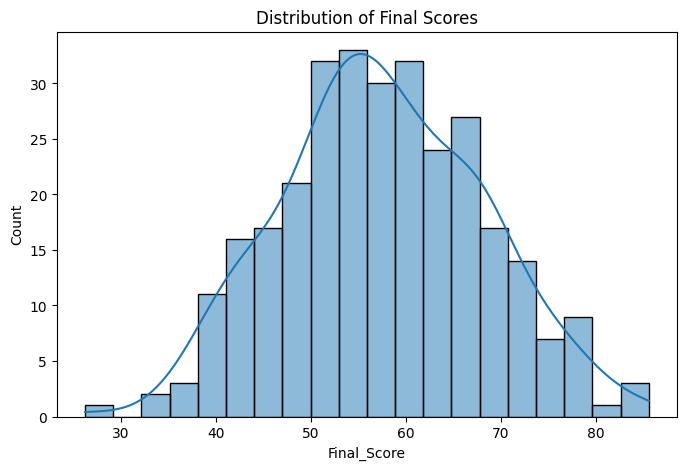

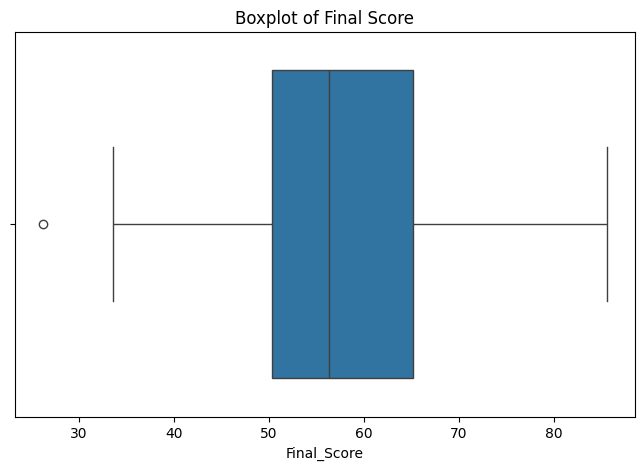

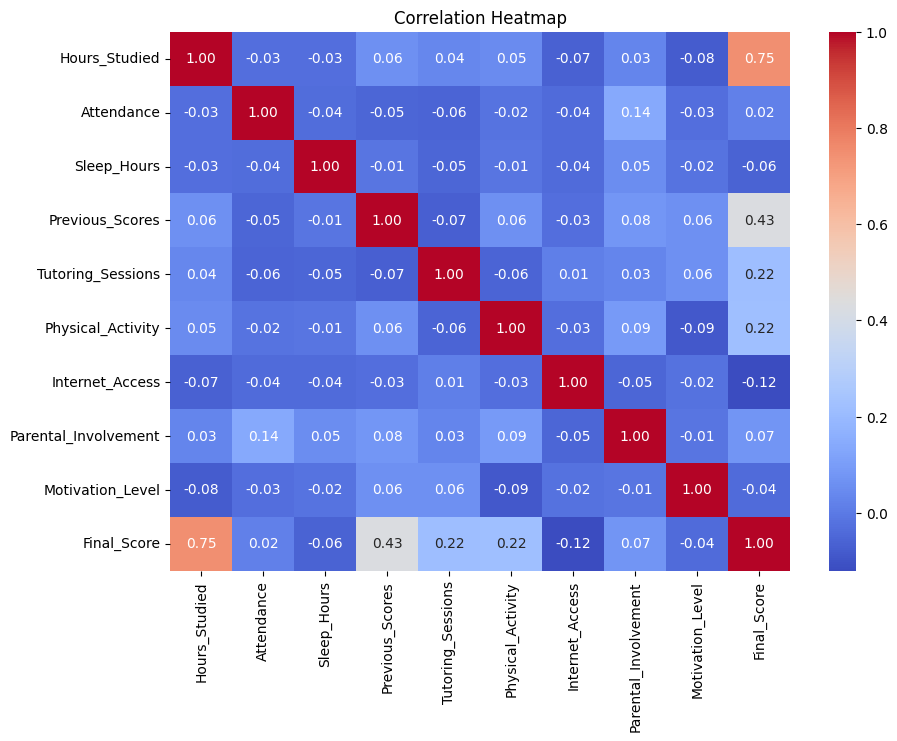

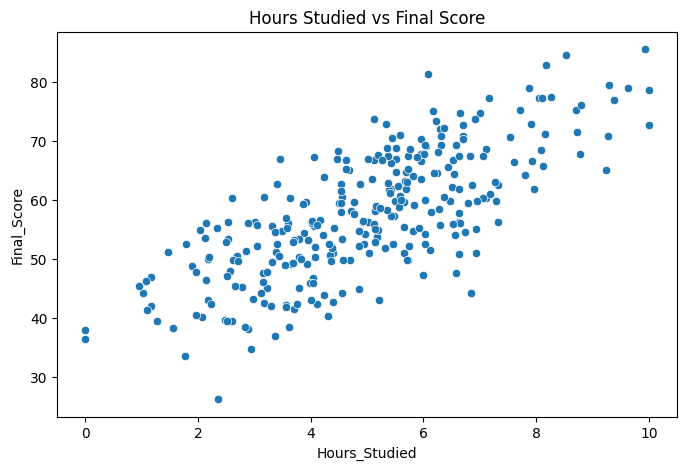

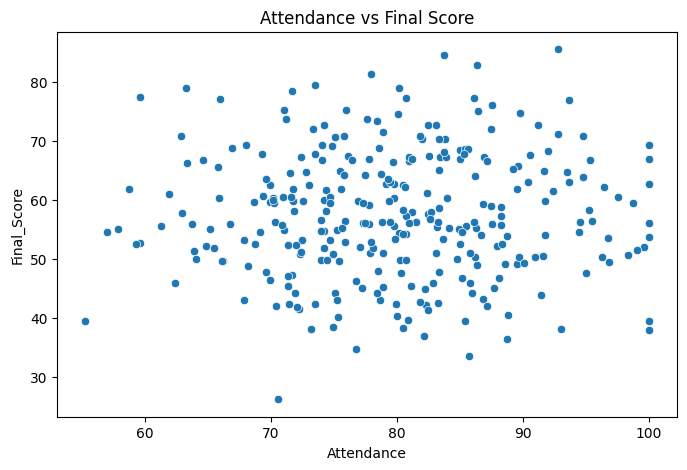


Linear Regression Results
R2 Score: 0.8117465916856912
MAE: 3.466628603069899
MSE: 20.302128913238693

Random Forest Results
R2 Score: 0.6875816861853681
MAE: 4.657604444444444
MSE: 33.692653634888885

Feature Importance:


,Feature,Importance
0,Hours_Studied,0.608242
3,Previous_Scores,0.192155
4,Tutoring_Sessions,0.053583
5,Physical_Activity,0.052884
1,Attendance,0.036154
2,Sleep_Hours,0.033951
7,Parental_Involvement,0.009345
8,Motivation_Level,0.009262
6,Internet_Access,0.004423


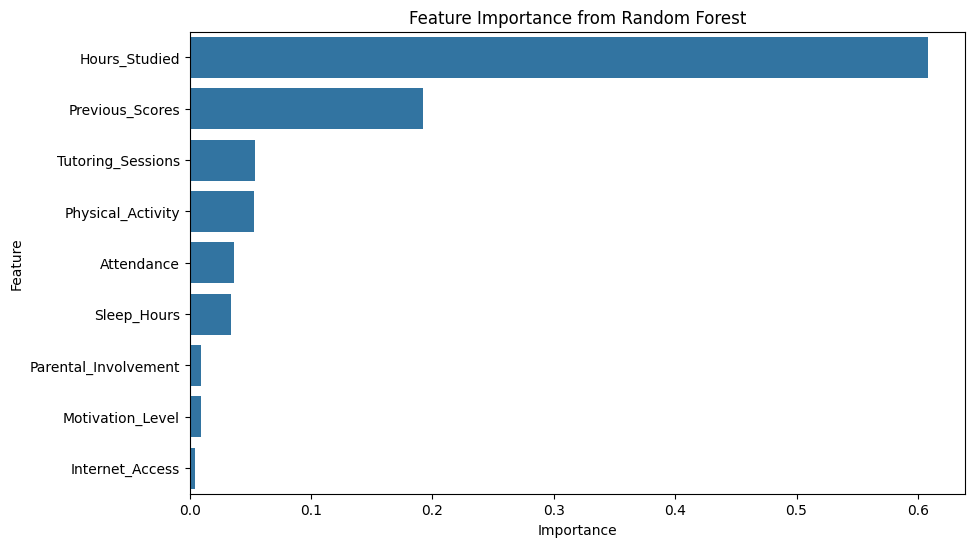

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/student_performance_dataset.csv")

# Preview
print("First 5 rows:")
display(df.head())

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Encode categorical columns
categorical_cols = df.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nData after encoding:")
display(df.head())

print("\nDescriptive statistics:")
display(df.describe())

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Final_Score"], bins=20, kde=True)
plt.title("Distribution of Final Scores")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Final_Score"])
plt.title("Boxplot of Final Score")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots
plt.figure(figsize=(8,5))
sns.scatterplot(x="Hours_Studied", y="Final_Score", data=df)
plt.title("Hours Studied vs Final Score")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Attendance", y="Final_Score", data=df)
plt.title("Attendance vs Final Score")
plt.show()

# Features and target
X = df.drop("Final_Score", axis=1)
y = df["Final_Score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\nLinear Regression Results")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Results")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance from Random Forest")
plt.show()

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Sleep_Hours,0
Previous_Scores,0
Tutoring_Sessions,0
Physical_Activity,0
Internet_Access,0
Parental_Involvement,0
Motivation_Level,0
Final_Score,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Hours_Studied         300 non-null    float64
 1   Attendance            300 non-null    float64
 2   Sleep_Hours           300 non-null    float64
 3   Previous_Scores       300 non-null    float64
 4   Tutoring_Sessions     300 non-null    int64  
 5   Physical_Activity     300 non-null    float64
 6   Internet_Access       300 non-null    object 
 7   Parental_Involvement  300 non-null    object 
 8   Motivation_Level      300 non-null    object 
 9   Final_Score           300 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 23.6+ KB


In [ ]:
df.shape

(300, 10)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/student_performance_dataset.csv")
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Internet_Access,Parental_Involvement,Motivation_Level,Final_Score
0,5.99,71.71,8.14,75.53,0,1.11,Yes,Medium,Medium,47.22
1,4.72,74.40,5.62,64.10,5,1.70,Yes,Low,Medium,58.17
2,6.30,87.47,8.30,70.43,1,3.09,No,Medium,Medium,72.07
3,8.05,86.10,9.03,89.18,3,3.74,No,Medium,Low,77.30
4,4.53,79.79,7.62,72.87,2,4.44,Yes,Medium,Medium,62.75
